# State Load Generation

This notebook shows the state-load step used by the state-level paper workflow. It uses the packaged `wxdata` TAIESM1/GCAM inputs and mirrors the TELL quickstarter forward-execution pattern from the point where BA hourly load forecasts already exist.

The reviewer path is:

1. Locate the packaged paper-data inputs.
2. Prepare a small TELL-shaped scratch folder under `paper_data/notebook_outputs/`.
3. Run `tell.execute_forward(...)` for one Iowa example year and GCAM case.
4. Compare the notebook output to the packaged Iowa state-load Parquet.
5. Plot the TELL-style state and BA load outputs.
6. Show the full 2000-2099 Iowa annual load trajectories for raw plus all GCAM-scaled cases.

The scratch folder only adapts file layout and column names for TELL. It is not a separate dataset and it is not the source of truth; the packaged state-load Parquet remains the archived product used downstream.

## 1. Import Packages

In [1]:
# Start by importing packages used in this notebook:
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="pkg_resources is deprecated as an API.*",
        category=UserWarning,
    )
    import tell

from IPython.display import display

pd.options.display.max_columns = 80


## 2. Locate Packaged Inputs

This section only defines paths and checks that the packaged inputs exist. The inputs come from this repository's paper-data package, not from the TELL quickstarter sample dataset.

The displayed manifest is the useful reviewer-facing output: it shows which archived inputs are used before any TELL-shaped scratch files are created.

In [2]:
# Point directly to the packaged inputs and notebook scratch-output folders.
source_bundle = "taiesm1_historical_ssp245_v022"
period_label = "2000_2099"
STATE_ABBR = "IA"
STATE_NAME = "Iowa"
year_to_process = "2039"
gcam_target_year = "2039"
scenario_to_process = "rcp85hotter_ssp5"

DATA_ROOT = Path("../data")
wxdata_data_dir = DATA_ROOT / f"{source_bundle}_{period_label}"
notebook_output_dir = Path("../notebook_outputs/data_flow/state_load_generation")
tell_data_dir = notebook_output_dir / "tell_data"
tell_image_dir = tell_data_dir / "visualizations"

ba_load_dir = wxdata_data_dir / "ba_load"
state_load_path = wxdata_data_dir / "state_load" / f"{STATE_ABBR}_{source_bundle}_{period_label}_load.parquet"
ba_mapping_path = DATA_ROOT / "source_inputs" / "county_weather_provenance" / "ba_service_territory_2019.csv"
static_population_path = DATA_ROOT / "source_inputs" / "population" / "static_county_population_2020_2000_2099.csv"
gcam_usa_source_dir = DATA_ROOT / "source_inputs" / "gcam_usa"

notebook_output_dir.mkdir(parents=True, exist_ok=True)
tell_image_dir.mkdir(parents=True, exist_ok=True)

input_manifest = pd.DataFrame(
    [
        ("BA hourly load forecasts", ba_load_dir),
        ("Packaged Iowa state load", state_load_path),
        ("BA service-territory map", ba_mapping_path),
        ("Static county population", static_population_path),
        ("GCAM-USA demand files", gcam_usa_source_dir),
    ],
    columns=["input", "path"],
)
input_manifest["exists"] = input_manifest["path"].map(lambda path: Path(path).exists())
if not input_manifest["exists"].all():
    missing = input_manifest.loc[~input_manifest["exists"], "path"].astype(str)
    raise FileNotFoundError("Missing required notebook input(s):\n" + "\n".join(missing))

display(input_manifest)


,input,path,exists
0,BA hourly load forecasts,..\data\taiesm1_historical_ssp245_v022_2000_20...,True
1,Packaged Iowa state load,..\data\taiesm1_historical_ssp245_v022_2000_20...,True
2,BA service-territory map,..\data\source_inputs\county_weather_provenanc...,True
3,Static county population,..\data\source_inputs\population\static_county...,True
4,GCAM-USA demand files,..\data\source_inputs\gcam_usa,True


## 3. Prepare TELL-Compatible Scratch Inputs

`tell.execute_forward(...)` expects the quickstarter-style directory layout. The next three cells create that layout under `paper_data/notebook_outputs/`, then copy or reshape the packaged `wxdata` inputs into that layout.

This is intentionally a staging step. The methodology remains the TELL forward-execution method:

```text
BA hourly load -> county population allocation -> state hourly load -> GCAM-USA scaling
```

### 3.1. Create The TELL-Style Scratch Folders

This creates empty folders with the same roles as the TELL quickstarter inputs: service-territory mapping, MLP load outputs, GCAM-USA forcing, population projections, and TELL output.

In [3]:
# Create the TELL quickstarter-like folder layout used by tell.execute_forward:
tell_quickstarter_dir = tell_data_dir / "tell_quickstarter_data"
sample_forcing_dir = tell_data_dir / "sample_forcing_data"

data_output_dir = tell_quickstarter_dir / "outputs" / "tell_output"
map_input_dir = tell_quickstarter_dir / "outputs" / "ba_service_territory"
mlp_input_dir = tell_quickstarter_dir / "outputs" / "mlp_output"
gcam_usa_input_dir = sample_forcing_dir / "sample_gcam_usa_data"
pop_input_dir = sample_forcing_dir / "sample_population_projections"

for path in [data_output_dir, map_input_dir, mlp_input_dir, gcam_usa_input_dir, pop_input_dir]:
    path.mkdir(parents=True, exist_ok=True)

### 3.2. Stage The Service-Territory Map And Static Population

Iowa load is assembled from `AECI`, `MISO_0035`, and `SWPP`. The staged service-territory map keeps **all** counties served by those three BAs, including counties outside Iowa, so TELL calculates each BA's county-population denominator before allocating its load to Iowa.

The population input is static `pop_2020`, repeated across 2000-2099 in a TELL-shaped file. That keeps the code path close to TELL while making the population assumption explicit.


In [4]:
# Keep every county served by the three BAs that contribute to Iowa.
IOWA_BA_CODES = ["AECI", "MISO_0035", "SWPP"]
full_ba_mapping_df = pd.read_csv(ba_mapping_path)
ba_mapping_df = full_ba_mapping_df[full_ba_mapping_df["BA_Code"].isin(IOWA_BA_CODES)].copy()
missing_mapping_bas = sorted(set(IOWA_BA_CODES) - set(ba_mapping_df["BA_Code"]))
if missing_mapping_bas:
    raise AssertionError(f"Missing service-territory rows for Iowa contributor BAs: {missing_mapping_bas}")
ba_mapping_df.to_csv(map_input_dir / "ba_service_territory_2019.csv", index=False)

# Stage static 2020 population as TELL-shaped SSP population files.
population_df = pd.read_csv(static_population_path)
county_state_df = full_ba_mapping_df[["County_FIPS", "State_Name"]].drop_duplicates("County_FIPS")
population_wide = population_df.pivot(index="County_FIPS", columns="Year", values="Population").reset_index()
population_wide = population_wide.merge(county_state_df, on="County_FIPS", how="left")
population_wide["State_Name"] = population_wide["State_Name"].fillna("Unused")
year_columns = [column for column in population_wide.columns if isinstance(column, int)]
population_wide = population_wide.rename(columns={"County_FIPS": "FIPS", "State_Name": "state_name"})
population_wide = population_wide[["FIPS", "state_name", *year_columns]]
for ssp in ["ssp3", "ssp5"]:
    population_wide.to_csv(pop_input_dir / f"{ssp}_county_population.csv", index=False)


### 3.3. Stage GCAM-USA Demand And One Year Of BA Load

The GCAM-USA file selected by `scenario_to_process` is copied into the TELL-style forcing folder. The BA load files are filtered to the example year and renamed into TELL's `mlp_output` shape.

This notebook stages one example year because the goal is to mirror TELL's forward-execution call for a reviewer. The operational state builder creates the full 2000-2099 archived state-load products.

In [5]:
# Stage the GCAM-USA file selected for this example.
gcam_usa_source_path = gcam_usa_source_dir / f"electricity_demand_{scenario_to_process}.csv"
if not gcam_usa_source_path.exists():
    raise FileNotFoundError(f"Missing GCAM-USA input: {gcam_usa_source_path}")
gcam_usa_staged_path = gcam_usa_input_dir / gcam_usa_source_path.name
shutil.copy2(gcam_usa_source_path, gcam_usa_staged_path)

# Stage BA load projections in TELL's mlp_output shape:
mlp_year_dir = mlp_input_dir / scenario_to_process / year_to_process
mlp_year_dir.mkdir(parents=True, exist_ok=True)
staged_ba_codes = []
for ba_code in IOWA_BA_CODES:
    source_path = ba_load_dir / f"{ba_code}_{source_bundle}_{period_label}_load.csv"
    if not source_path.exists():
        raise FileNotFoundError(f"Missing {year_to_process} BA load input for Iowa contributor BA: {source_path}")
    frame = pd.read_csv(source_path, parse_dates=["time_utc"])
    frame = frame[frame["time_utc"].dt.year.eq(int(year_to_process))].copy()
    frame = frame.rename(columns={"time_utc": "Time_UTC", "load_mw": "Load"})
    frame["BA"] = ba_code
    frame[["Time_UTC", "Load", "BA"]].to_csv(mlp_year_dir / f"{ba_code}_{year_to_process}_mlp_output.csv", index=False)
    staged_ba_codes.append(ba_code)


### 3.4. Review The Staged Scratch Inputs

This manifest is the checkpoint before calling TELL. If the counts look wrong, the problem is in staging, not in `tell.execute_forward(...)`.

In [6]:
staging_manifest = pd.DataFrame({
    "check": [
        "contributor_ba_codes",
        "service_territory_membership_rows",
        "unique_counties_across_contributor_bas",
        "population_ssp3_file",
        "population_ssp5_file",
        "gcam_usa_file",
        "mlp_output_files",
    ],
    "value": [
        ", ".join(sorted(staged_ba_codes)),
        len(ba_mapping_df),
        ba_mapping_df["County_FIPS"].nunique(),
        (pop_input_dir / "ssp3_county_population.csv").exists(),
        (pop_input_dir / "ssp5_county_population.csv").exists(),
        gcam_usa_staged_path.name,
        len(staged_ba_codes),
    ],
})
display(staging_manifest)


,check,value
0,contributor_ba_codes,"AECI, MISO_0035, SWPP"
1,service_territory_membership_rows,964
2,unique_counties_across_contributor_bas,771
3,population_ssp3_file,True
4,population_ssp5_file,True
5,gcam_usa_file,electricity_demand_rcp85hotter_ssp5.csv
6,mlp_output_files,3


## 4. Model Forward Execution

This is the required offline TELL forward-execution step. The upstream MLP training step has already been handled by the wxdata BA load workflow and is intentionally not repeated here. Every code cell in this section reads the packaged or staged local inputs.


In [7]:
# Run the TELL model forward in time for a given year:
summary_df, ba_time_series_df, state_time_series_df = tell.execute_forward(
    year_to_process=year_to_process,
    gcam_target_year=gcam_target_year,
    scenario_to_process=scenario_to_process,
    data_output_dir=str(data_output_dir),
    gcam_usa_input_dir=str(gcam_usa_input_dir),
    map_input_dir=str(map_input_dir),
    mlp_input_dir=str(mlp_input_dir),
    pop_input_dir=str(pop_input_dir),
    save_county_data=False,
)

Scenario =  rcp85hotter_ssp5 , Year =  2039
Elapsed time =  0:00:19.034500


In [8]:
# View the state summary and Iowa hourly state load returned by TELL:
display(summary_df[summary_df["State_Name"].eq(STATE_NAME)])
display(state_time_series_df[state_time_series_df["State_Name"].eq(STATE_NAME)].head(10))

,Year,State_Name,State_FIPS,Scaling_Factor,GCAM_USA_Load_TWh,Raw_TELL_Load_TWh,Scaled_TELL_Load_TWh
99,2039,Iowa,19000.0,1.2844,64.80358,50.45428,64.80358


,State_Name,State_FIPS,Time_UTC,Raw_TELL_State_Load_MWh,Scaled_TELL_State_Load_MWh
99,Iowa,19000.0,2039-01-01 00:00:00+00:00,5705.54,7328.21
261,Iowa,19000.0,2039-01-01 01:00:00+00:00,5769.87,7410.84
423,Iowa,19000.0,2039-01-01 02:00:00+00:00,5738.26,7370.23
585,Iowa,19000.0,2039-01-01 03:00:00+00:00,5661.57,7271.73
747,Iowa,19000.0,2039-01-01 04:00:00+00:00,5548.41,7126.38
909,Iowa,19000.0,2039-01-01 05:00:00+00:00,5395.84,6930.43
1071,Iowa,19000.0,2039-01-01 06:00:00+00:00,5323.49,6837.50
1233,Iowa,19000.0,2039-01-01 07:00:00+00:00,5209.93,6691.64
1395,Iowa,19000.0,2039-01-01 08:00:00+00:00,5100.41,6550.98
1557,Iowa,19000.0,2039-01-01 09:00:00+00:00,5045.90,6480.96


In [9]:
# Compare the one-year TELL forward-execution output to the packaged state load product:
packaged_load_df = pd.read_parquet(state_load_path)
packaged_load_df["time_utc"] = pd.to_datetime(packaged_load_df["time_utc"], utc=True)
packaged_2039 = packaged_load_df[
    packaged_load_df["time_utc"].dt.year.eq(int(year_to_process))
].copy()

iowa_tell = state_time_series_df[
    state_time_series_df["State_Name"].eq(STATE_NAME)
].copy()
iowa_tell["Time_UTC"] = pd.to_datetime(iowa_tell["Time_UTC"], utc=True)

if iowa_tell["Time_UTC"].duplicated().any() or packaged_2039["time_utc"].duplicated().any():
    raise AssertionError("TELL or packaged Iowa timestamps are not unique.")

comparison = iowa_tell.merge(
    packaged_2039,
    left_on="Time_UTC",
    right_on="time_utc",
    validate="one_to_one",
)
if len(comparison) != len(iowa_tell) or len(comparison) != len(packaged_2039):
    raise AssertionError("TELL and packaged Iowa timestamps do not align one-to-one.")

comparison_df = pd.DataFrame({
    "hours_compared": [len(comparison)],
    "raw_max_abs_diff_mw": [
        (
            comparison["Raw_TELL_State_Load_MWh"]
            - comparison["load_mw__raw"]
        ).abs().max()
    ],
    "scaled_max_abs_diff_mw": [
        (
            comparison["Scaled_TELL_State_Load_MWh"]
            - comparison[f"load_mw__gcam_{scenario_to_process}"]
        ).abs().max()
    ],
    "rounding_tolerance_mw": [0.0051],
})
if not (
    comparison_df[["raw_max_abs_diff_mw", "scaled_max_abs_diff_mw"]]
    .le(comparison_df["rounding_tolerance_mw"], axis=0)
    .all(axis=None)
):
    raise AssertionError("TELL output differs from the packaged Iowa load beyond rounding tolerance.")

display(comparison_df)


,hours_compared,raw_max_abs_diff_mw,scaled_max_abs_diff_mw,rounding_tolerance_mw
0,8760,0.004999,0.004998,0.0051


## 5. Model Visualization

### 5.1. Plot The State Annual Total Loads From GCAM-USA And TELL

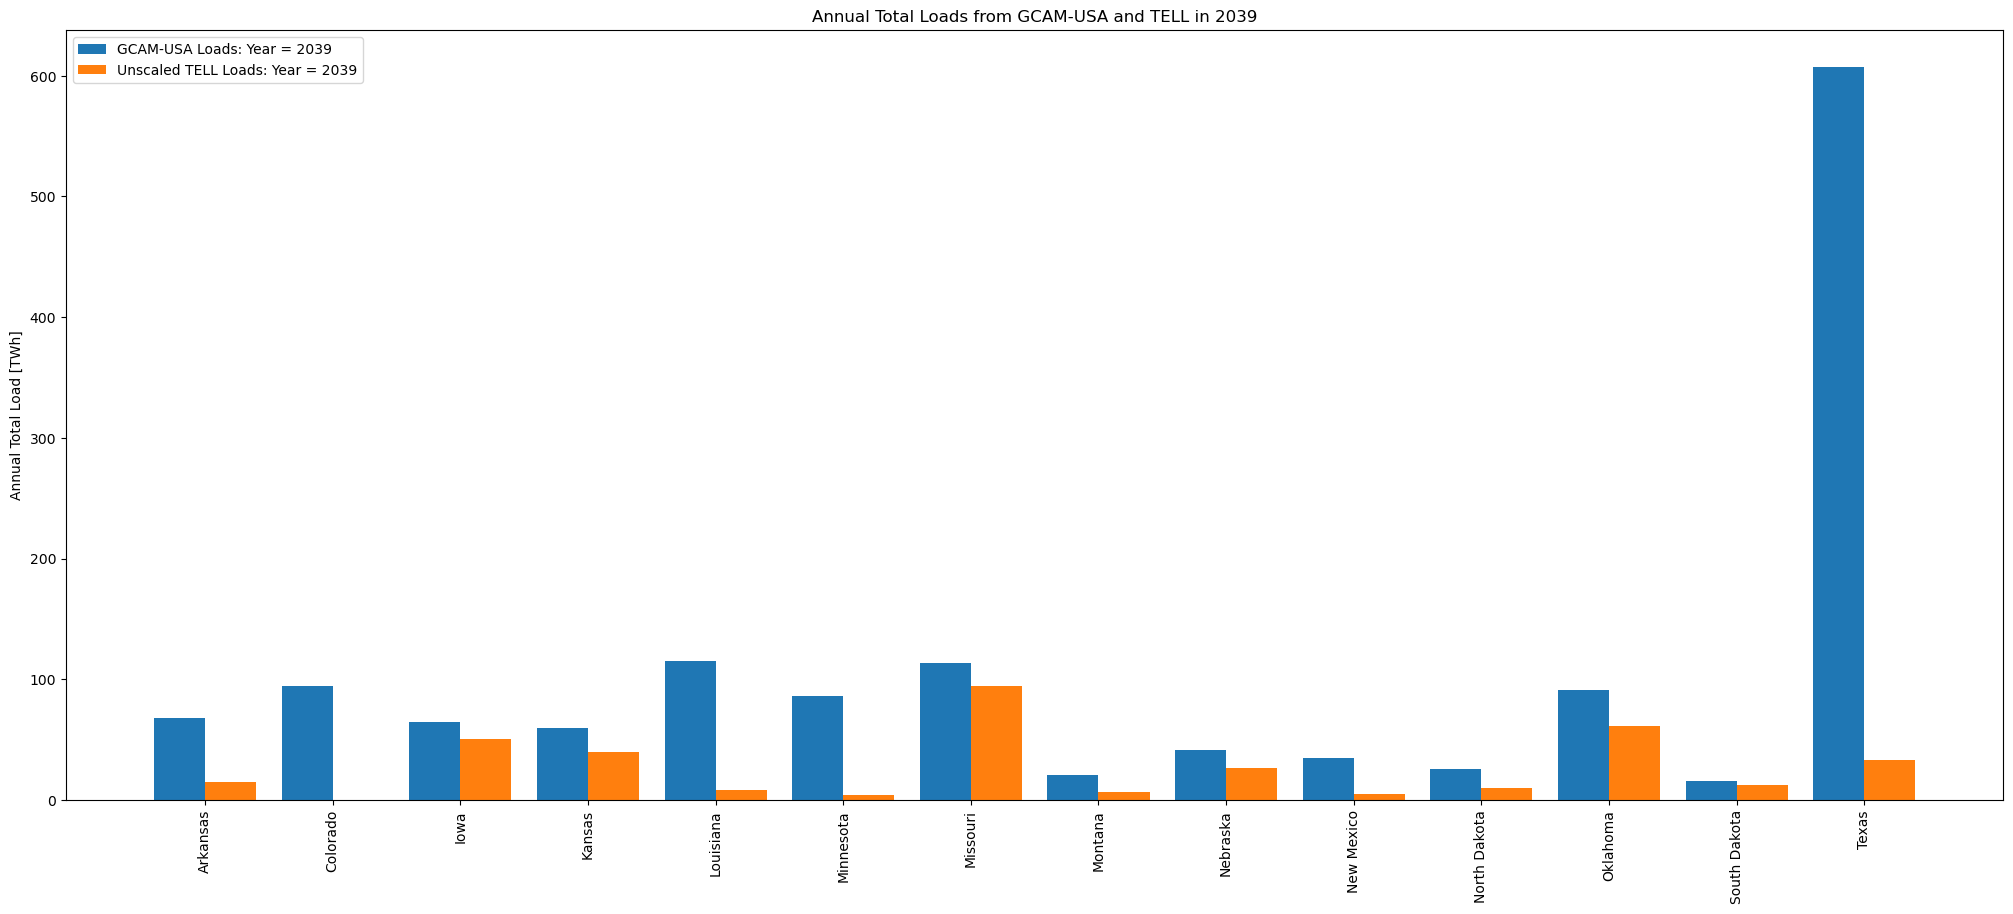

In [10]:
# Plot the annual total loads from both GCAM-USA and TELL:
tell.plot_state_annual_total_loads(
    year_to_plot=year_to_process,
    gcam_target_year=gcam_target_year,
    scenario_to_plot=scenario_to_process,
    data_input_dir=tell_data_dir,
    image_output_dir=tell_image_dir,
    image_resolution=150,
    save_images=False,
)

### 5.2. Plot The Time-Series Of Total Hourly Loads For A Given State

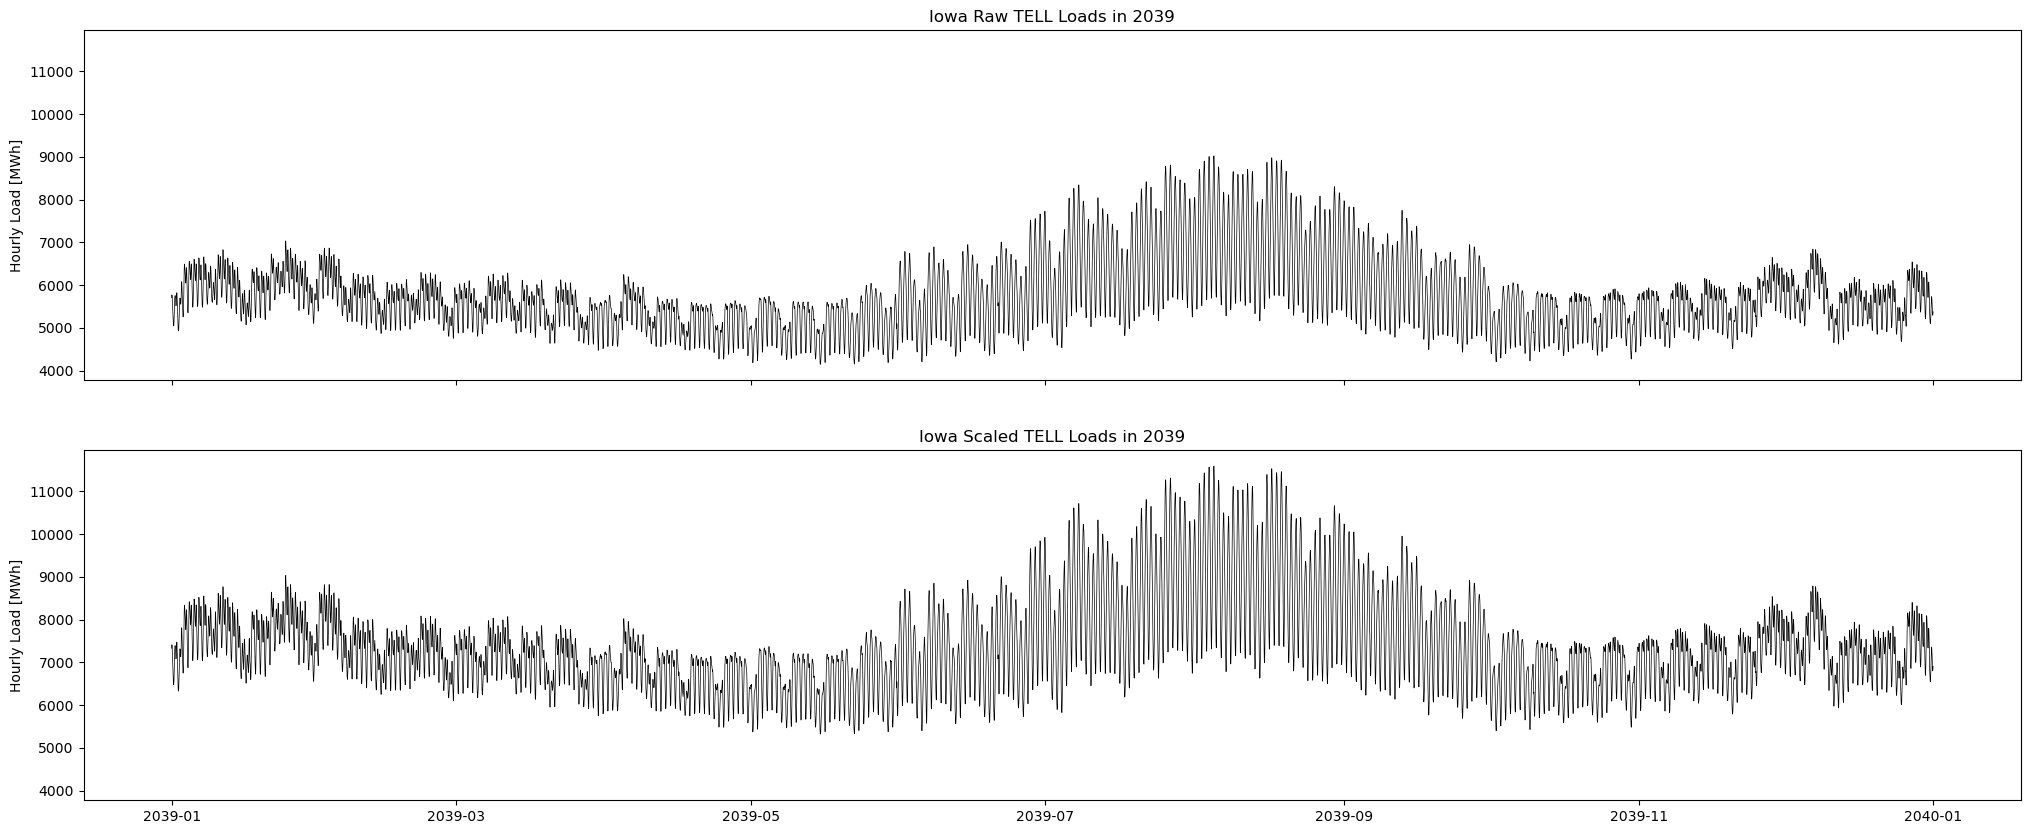

In [11]:
# Plot the time-series of raw and scaled loads from TELL at the state level for a user-specified state:
tell.plot_state_load_time_series(
    state_to_plot=STATE_NAME,
    year_to_plot=year_to_process,
    gcam_target_year=gcam_target_year,
    scenario_to_plot=scenario_to_process,
    data_input_dir=tell_data_dir,
    image_output_dir=tell_image_dir,
    image_resolution=150,
    save_images=False,
)

### 5.3. Plot The Load Duration Curve For A Given State

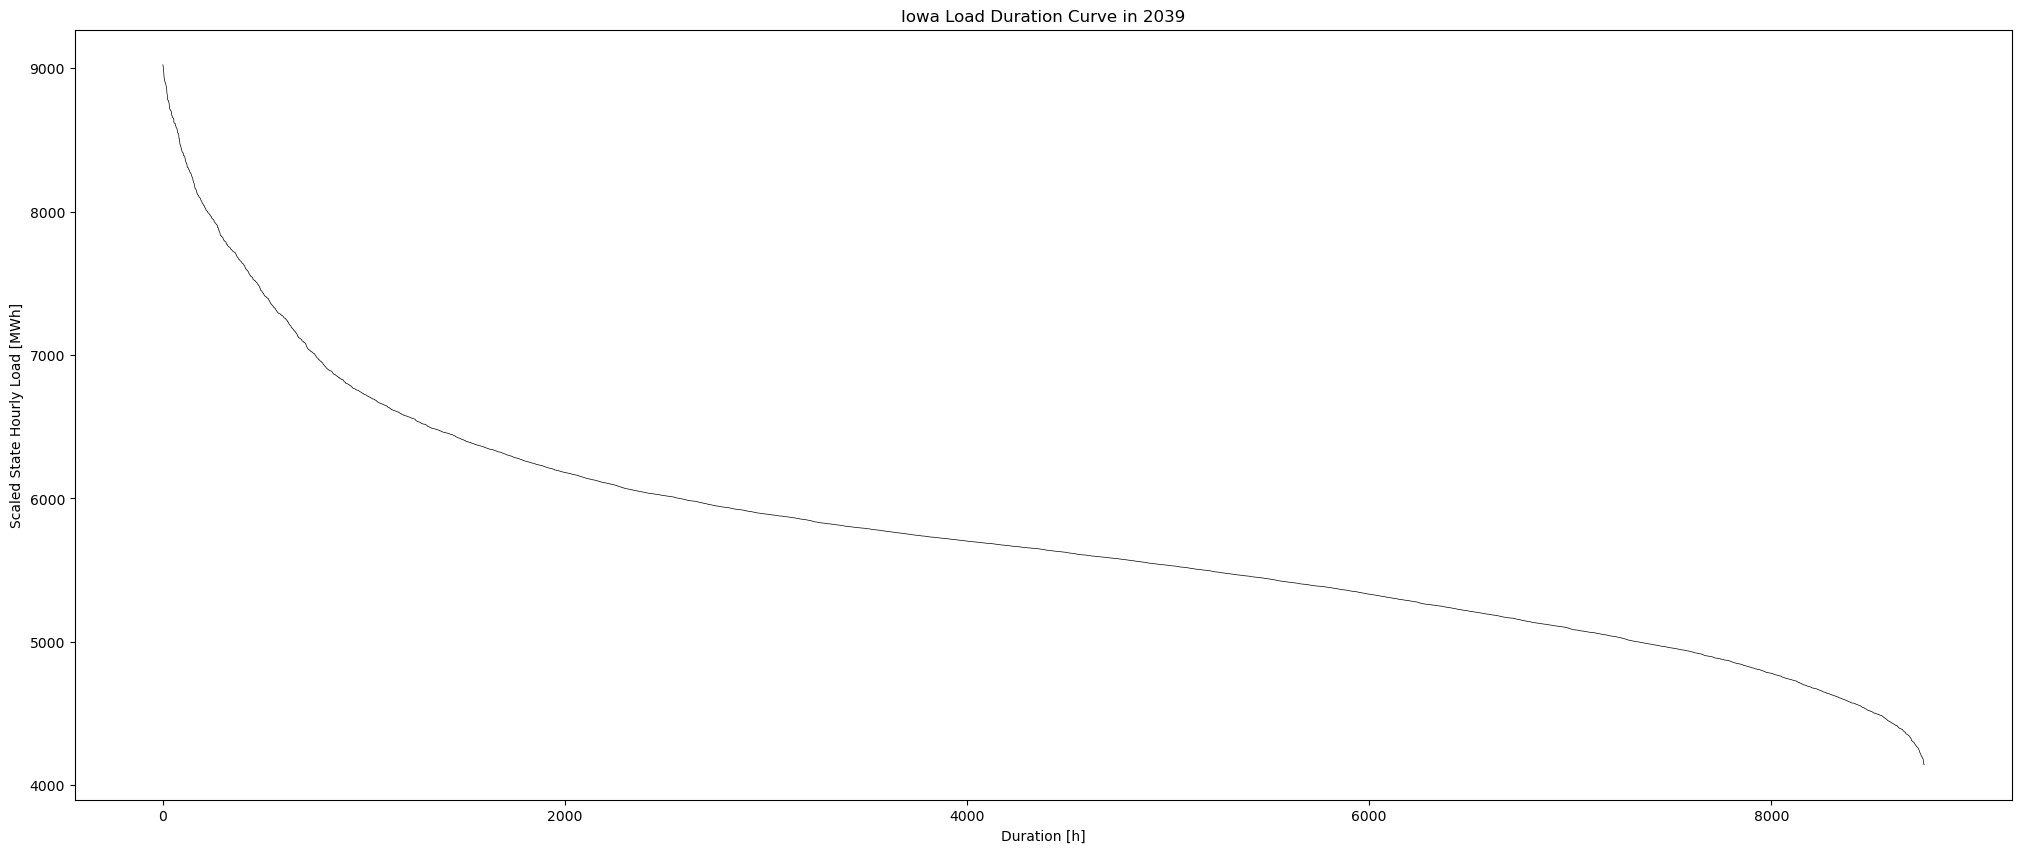

In [12]:
# Plot the load duration curve at the state level for a user-specified state:
tell.plot_state_load_duration_curve(
    state_to_plot=STATE_NAME,
    year_to_plot=year_to_process,
    gcam_target_year=gcam_target_year,
    scenario_to_plot=scenario_to_process,
    data_input_dir=tell_data_dir,
    image_output_dir=tell_image_dir,
    image_resolution=150,
    save_images=False,
)

### 5.4. Plot The Time-Series Of Total Hourly Loads For A Given BA

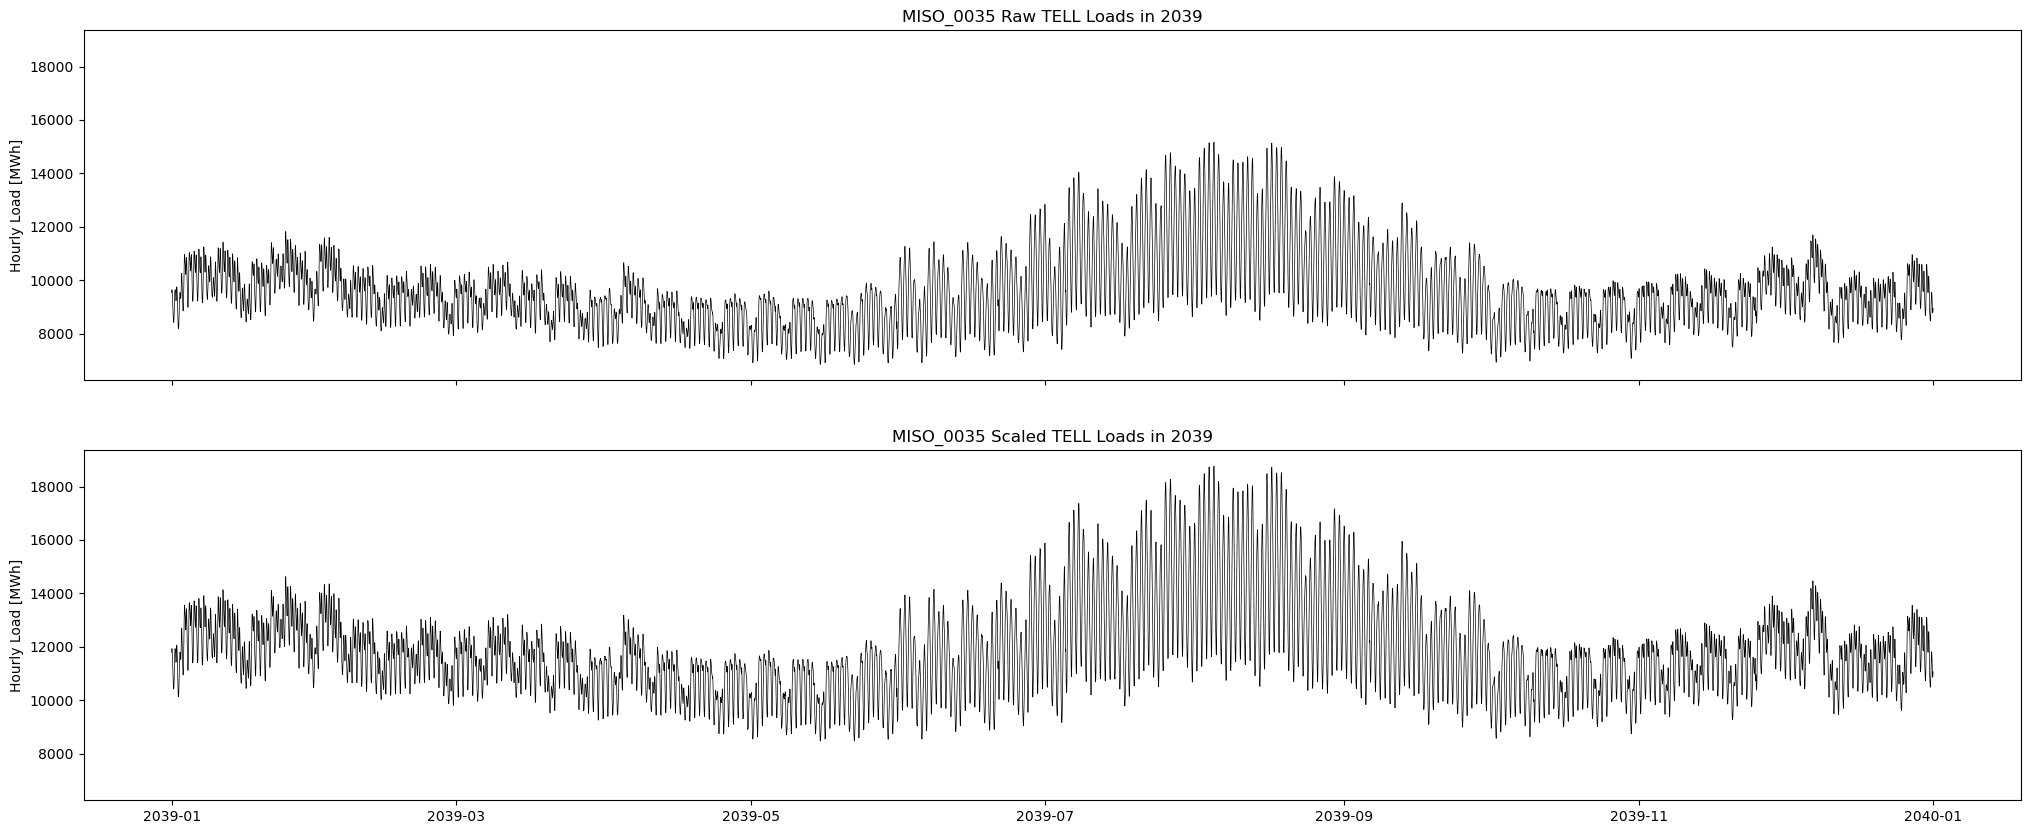

In [13]:
# Plot the time-series of raw and scaled loads from TELL at the BA level for a user-specified BA:
tell.plot_ba_load_time_series(
    ba_to_plot="MISO_0035",
    year_to_plot=year_to_process,
    gcam_target_year=gcam_target_year,
    scenario_to_plot=scenario_to_process,
    data_input_dir=tell_data_dir,
    image_output_dir=tell_image_dir,
    image_resolution=150,
    save_images=False,
)

## 6. Iowa Annual Load Cases

The TELL example above shows one year and one GCAM case. This final section returns to the packaged Iowa state-load Parquet and plots the full 2000-2099 annual load trajectories for raw plus all 8 GCAM-scaled cases.

This is the handoff to downstream notebooks: state scenario metrics and load-growth planning consume these load columns directly.

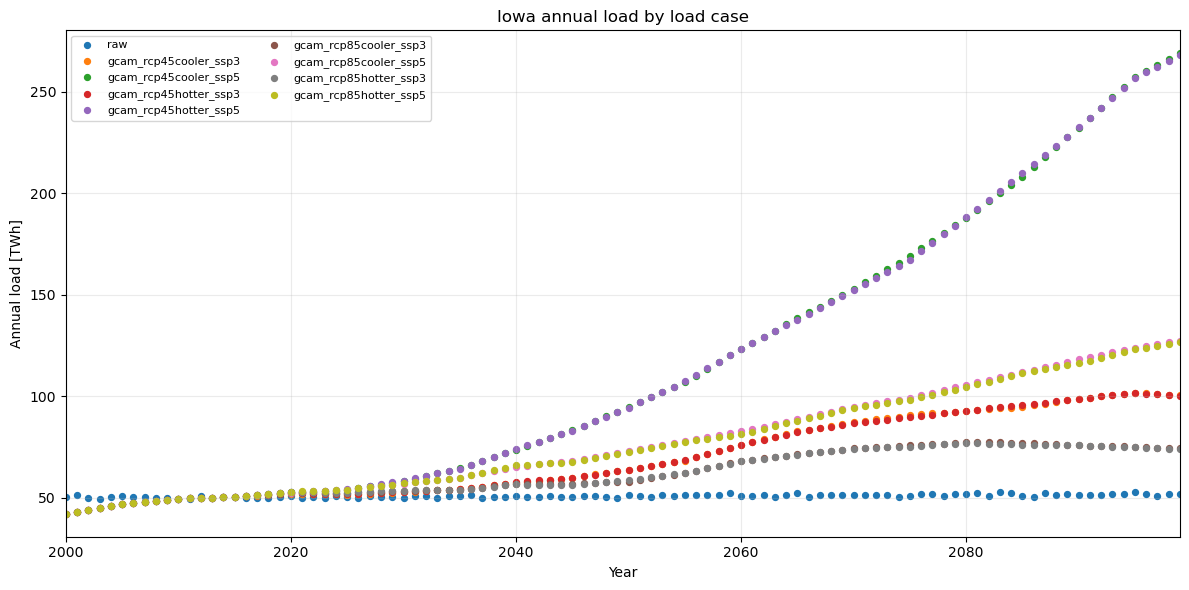

Wrote plot: notebook_outputs\data_flow\state_load_generation\tell_data\visualizations\IA_2000_2099_annual_load_cases_scatter.png


,year,load_case,annual_load_twh
0,2000,raw,50.219208
1,2001,raw,51.311131
2,2002,raw,49.777664
3,2003,raw,49.552772
4,2004,raw,50.504927
5,2005,raw,51.120045
6,2006,raw,50.618770
7,2007,raw,50.578611
8,2008,raw,49.749959
9,2009,raw,50.170596


In [14]:
# Plot annual Iowa load trajectories for raw plus all GCAM-scaled load cases:
state_load = packaged_load_df.copy()
state_load["year"] = state_load["time_utc"].dt.year


expected_years = set(range(2000, 2100))
actual_years = set(state_load["year"].unique())
if actual_years != expected_years:
    raise AssertionError(
        f"Expected complete 2000-2099 Iowa load coverage; missing={sorted(expected_years - actual_years)}, "
        f"extra={sorted(actual_years - expected_years)}"
    )

load_case_columns = [column for column in state_load.columns if column.startswith("load_mw__")]
annual_load = (
    state_load
    .groupby("year", as_index=False)[load_case_columns]
    .sum()
    .melt(id_vars="year", var_name="load_case", value_name="annual_load_twh")
)
annual_load["annual_load_twh"] = annual_load["annual_load_twh"] / 1_000_000.0
annual_load["load_case"] = annual_load["load_case"].str.replace("load_mw__", "", regex=False)

load_case_order = [
    "raw",
    "gcam_rcp45cooler_ssp3",
    "gcam_rcp45cooler_ssp5",
    "gcam_rcp45hotter_ssp3",
    "gcam_rcp45hotter_ssp5",
    "gcam_rcp85cooler_ssp3",
    "gcam_rcp85cooler_ssp5",
    "gcam_rcp85hotter_ssp3",
    "gcam_rcp85hotter_ssp5",
]
missing_cases = set(load_case_order) - set(annual_load["load_case"])
if missing_cases:
    raise AssertionError(f"Missing load case(s): {sorted(missing_cases)}")
extra_cases = set(annual_load["load_case"]) - set(load_case_order)
if extra_cases:
    raise AssertionError(f"Unexpected load case(s): {sorted(extra_cases)}")
fig, ax = plt.subplots(figsize=(12, 6))
for load_case in load_case_order:
    case_rows = annual_load[annual_load["load_case"].eq(load_case)]
    ax.scatter(case_rows["year"], case_rows["annual_load_twh"], s=18, label=load_case)

ax.set_title(f"{STATE_NAME} annual load by load case")
ax.set_xlabel("Year")
ax.set_ylabel("Annual load [TWh]")
ax.set_xlim(2000, 2099)
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

load_case_plot_path = tell_image_dir / f"{STATE_ABBR}_{period_label}_annual_load_cases_scatter.png"
fig.savefig(load_case_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Wrote plot: {load_case_plot_path.relative_to(Path('..'))}")
display(annual_load.head(18))
